<a href="https://colab.research.google.com/github/JonathanDP02/244107020197-Pembelajaran-Mobile/blob/main/JS05_Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


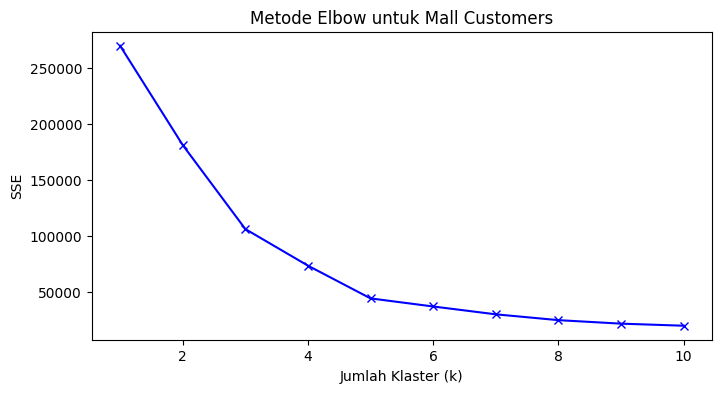

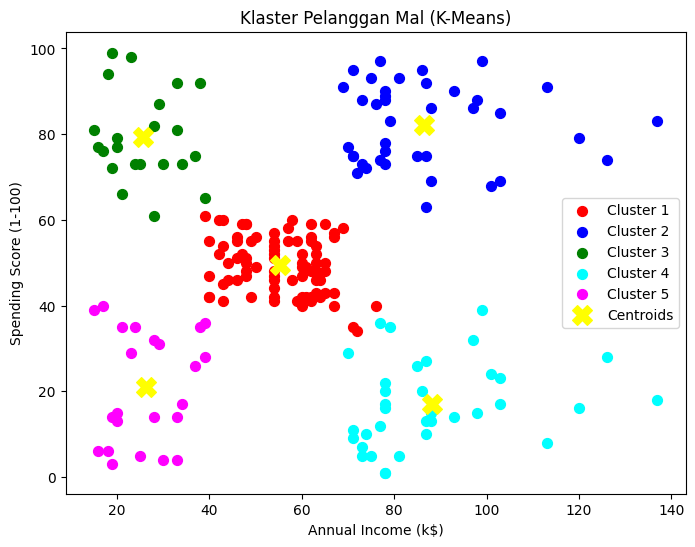

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Load dataset
df = pd.read_csv('/content/Mall_Customers.csv')
print(df.head())

# 2. Seleksi Fitur (Mengambil kolom Annual Income dan Spending Score)
# Kolom ke-3 (Annual Income) dan ke-4 (Spending Score) jika berbasis 0-index
X = df.iloc[:, [3, 4]].values

# 3. Mencari k terbaik menggunakan Metode Elbow
sse = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 4))
plt.plot(K, sse, 'bx-')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('SSE')
plt.title('Metode Elbow untuk Mall Customers')
plt.show()

# Berdasarkan grafik elbow, titik siku (elbow) biasanya berada di k = 5
# 4. Membuat model K-Means dengan k optimal (k=5)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)

# 5. Visualisasi Hasil Klaster
plt.figure(figsize=(8, 6))
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=50, c='red', label='Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=50, c='blue', label='Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=50, c='green', label='Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=50, c='cyan', label='Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=50, c='magenta', label='Cluster 5')

# Plot Centroid
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], s=200, c='yellow', marker='X', label='Centroids')
plt.title('Klaster Pelanggan Mal (K-Means)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

Jumlah Klaster: 2
Jumlah Noise: 0
Homogeneity: 1.000
Completeness: 1.000
V-measure: 1.000
ARI: 1.000
AMI: 1.000
Silhouette Score: 0.391


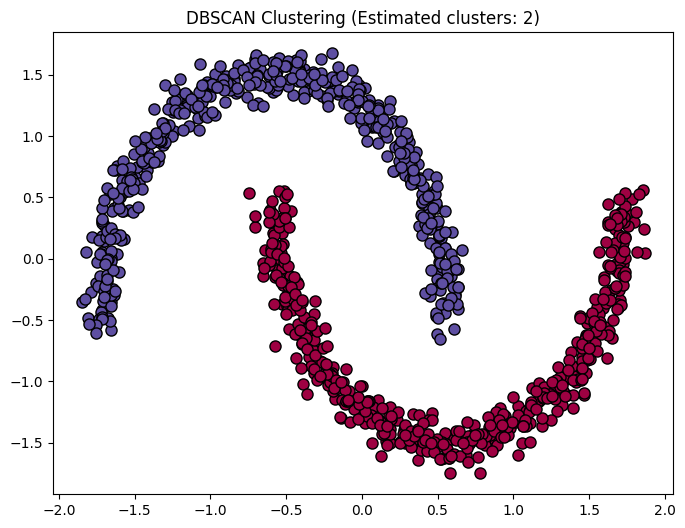


--- HASIL EKSPERIMEN ---
eps=0.05, min_samples=3 --> Klaster: 69, Noise: 186, Silhouette: 0.11292949852882253
eps=0.05, min_samples=10 --> Klaster: 3, Noise: 970, Silhouette: -0.29419008256642176
eps=0.05, min_samples=20 --> Klaster: 0, Noise: 1000, Silhouette: N/A
eps=0.1, min_samples=3 --> Klaster: 2, Noise: 14, Silhouette: 0.2516903011504368
eps=0.1, min_samples=10 --> Klaster: 7, Noise: 57, Silhouette: 0.16230611373347142
eps=0.1, min_samples=20 --> Klaster: 6, Noise: 850, Silhouette: -0.3601946191938665
eps=0.3, min_samples=3 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403
eps=0.3, min_samples=10 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403
eps=0.3, min_samples=20 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403
eps=0.5, min_samples=3 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403
eps=0.5, min_samples=10 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403
eps=0.5, min_samples=20 --> Klaster: 2, Noise: 0, Silhouette: 0.3911598537138403


In [2]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn import metrics

# A. Buat dataset make_moons dan normalisasi
X, y_true = make_moons(n_samples=1000, noise=0.05, random_state=42)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# B. Jalankan DBSCAN dengan parameter awal (eps=0.2, min_samples=5)
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_dbscan = dbscan.fit_predict(X_scaled)

# Hitung jumlah klaster dan noise (noise ditandai dengan label -1)
n_clusters = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)
print(f"Jumlah Klaster: {n_clusters}")
print(f"Jumlah Noise: {n_noise}")

# C. Evaluasi Metrik
# Catatan: Silhouette score memerlukan minimal 2 klaster dan tidak boleh ada error jika semua jadi noise
labels = y_dbscan
homogeneity = metrics.homogeneity_score(y_true, labels)
completeness = metrics.completeness_score(y_true, labels)
v_measure = metrics.v_measure_score(y_true, labels)
ari = metrics.adjusted_rand_score(y_true, labels)
ami = metrics.adjusted_mutual_info_score(y_true, labels)
silhouette = metrics.silhouette_score(X_scaled, labels) if n_clusters > 1 else -1

print(f"Homogeneity: {homogeneity:.3f}")
print(f"Completeness: {completeness:.3f}")
print(f"V-measure: {v_measure:.3f}")
print(f"ARI: {ari:.3f}")
print(f"AMI: {ami:.3f}")
print(f"Silhouette Score: {silhouette:.3f}")

# D. Visualisasi Hasil DBSCAN
core_samples_mask = np.zeros_like(dbscan.labels_, dtype=bool)
core_samples_mask[dbscan.core_sample_indices_] = True

plt.figure(figsize=(8, 6))
unique_labels = set(y_dbscan)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # Warna hitam untuk noise

    class_member_mask = (y_dbscan == k)

    # Core samples (titik besar)
    xy = X_scaled[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=8)

    # Non-core samples / outliers (titik kecil)
    xy = X_scaled[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=3)

plt.title(f'DBSCAN Clustering (Estimated clusters: {n_clusters})')
plt.show()

# E. Eksperimen Parameter (eps dan min_samples)
eps_values = [0.05, 0.1, 0.3, 0.5]
min_samples_values = [3, 10, 20]

print("\n--- HASIL EKSPERIMEN ---")
for e in eps_values:
    for ms in min_samples_values:
        dbs = DBSCAN(eps=e, min_samples=ms)
        res = dbs.fit_predict(X_scaled)
        n_cl = len(set(res)) - (1 if -1 in res else 0)
        n_ns = list(res).count(-1)
        sil = metrics.silhouette_score(X_scaled, res) if n_cl > 1 else "N/A"
        print(f"eps={e}, min_samples={ms} --> Klaster: {n_cl}, Noise: {n_ns}, Silhouette: {sil}")